# 05 · Transformers y SBERT

**Parte 4 — vectores que cambian según la frase.** Word2Vec guarda **un solo
vector por palabra**, así que sus distintos sentidos tienen que compartir
esa única casilla. El español está lleno de casos de polisemia: "banco"
(asiento del parque / entidad financiera), "gato" (animal / herramienta del
auto), "sierra" (cadena de montañas / herramienta de cortar). Para separar
esos sentidos, el vector de una palabra tiene que construirse **mirando a
las palabras que la acompañan** — a eso se le llama *self-attention*.

## Comprobación: el mismo vector, dos contextos

Con un modelo Transformer real (el mismo `MiniLM` multilingüe que se usa
más abajo para SBERT) se extrae el vector interno de "banco" en dos frases
distintas y se compara.

In [6]:
import numpy as np
import torch
from transformers import AutoModel, AutoTokenizer

MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
modelo_base = AutoModel.from_pretrained(MODEL_NAME)
modelo_base.eval()


def vector_de_palabra(texto, palabra):
    # Vector contextual (último estado oculto) del primer token que cubre `palabra`
    codificado = tokenizer(texto, return_offsets_mapping=True, return_tensors="pt")
    offsets = codificado.pop("offset_mapping")[0]
    with torch.no_grad():
        estados = modelo_base(**codificado).last_hidden_state[0]

    inicio = texto.lower().index(palabra)
    fin = inicio + len(palabra)
    for i, (a, b) in enumerate(offsets.tolist()):
        if a < fin and b > inicio:
            return estados[i].numpy()
    raise ValueError(f"No se encontró {palabra!r} en {texto!r}")


def similitud_coseno(a, b):
    return a.dot(b) / (np.linalg.norm(a) * np.linalg.norm(b))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [7]:
frase_parque = "me senté en el banco del parque a descansar"
frase_dinero = "retiré dinero del banco esta mañana"

banco_parque = vector_de_palabra(frase_parque, "banco")
banco_dinero = vector_de_palabra(frase_dinero, "banco")
parque = vector_de_palabra(frase_parque, "parque")
dinero = vector_de_palabra(frase_dinero, "dinero")

print(f"cos(banco@parque, banco@dinero)  = {similitud_coseno(banco_parque, banco_dinero):.3f}   (mismo token, dos frases)")
print(f"cos(banco@parque, 'parque')      = {similitud_coseno(banco_parque, parque):.3f}   (mismo contexto)")
print(f"cos(banco@dinero, 'dinero')      = {similitud_coseno(banco_dinero, dinero):.3f}   (mismo contexto)")
print(f"cos(banco@parque, 'dinero')      = {similitud_coseno(banco_parque, dinero):.3f}   (contexto cruzado)")

cos(banco@parque, banco@dinero)  = 0.208   (mismo token, dos frases)
cos(banco@parque, 'parque')      = 0.712   (mismo contexto)
cos(banco@dinero, 'dinero')      = 0.715   (mismo contexto)
cos(banco@parque, 'dinero')      = 0.122   (contexto cruzado)


El vector de "banco" **no es el mismo** en las dos frases (el primer coseno
queda lejos de 1) y cada versión se acerca más a las palabras de su propio
contexto que al contexto de la otra frase. Con Word2Vec ese primer coseno
habría sido exactamente 1.0, porque solo existe un vector por palabra.

## Cómo lo logra: preguntar a los vecinos (self-attention)

Antes de fijar el vector de una palabra, el modelo revisa el resto de la
frase y se queda con lo que le sirve. Cada palabra genera tres versiones de
sí misma:

- **Query** — lo que esa palabra necesita saber ("¿de qué tipo de banco se
  habla?").
- **Key** — la etiqueta con la que se anuncia ("soy un lugar al aire
  libre").
- **Value** — la información que entrega si la eligen.

El cálculo tiene tres pasos: comparar la Query de una palabra contra la Key
de cada palabra de la frase, convertir esas comparaciones en porcentajes con
softmax, y mezclar los Value de todas usando esos porcentajes como pesos.

$$
\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V
$$

Dividir entre $\sqrt{d_k}$ evita que los productos se disparen y el softmax
termine dando 1.0 a una sola palabra y 0.0 al resto.

In [8]:
def softmax(x):
    x = x - x.max()
    e = np.exp(x)
    return e / e.sum()


def self_attention(query, keys, values):
    d_k = query.shape[-1]
    puntajes = keys @ query / np.sqrt(d_k)
    pesos = softmax(puntajes)
    return pesos, pesos @ values


# Vectores de juguete (3 dimensiones) solo para ilustrar el mecanismo,
# igual que el ejemplo de la diapositiva: "la cámara tiene buena calidad de imagen"
palabras = ["la", "cámara", "tiene", "buena", "calidad", "de", "imagen"]
K = np.array([
    [0.00, 0.00, 1.00],  # la      -> función gramatical, sin contenido
    [0.90, 0.70, 0.10],  # cámara  -> contenido visual
    [0.00, 0.10, 0.90],  # tiene   -> función gramatical
    [0.50, 0.60, 0.20],  # buena   -> valoración
    [1.00, 0.80, 0.00],  # calidad -> es la propia consulta
    [0.00, 0.00, 1.00],  # de      -> función gramatical
    [0.95, 0.75, 0.05],  # imagen  -> contenido visual
])
V = K.copy()  # simplificación: en un Transformer real, V se aprende por separado

query_calidad = K[palabras.index("calidad")]
pesos, mezcla = self_attention(query_calidad, K, V)

for palabra, peso in zip(palabras, pesos):
    barra = "█" * int(peso * 40)
    print(f"{palabra:8} {peso:.3f}  {barra}")

la       0.082  ███
cámara   0.191  ███████
tiene    0.086  ███
buena    0.145  █████
calidad  0.212  ████████
de       0.082  ███
imagen   0.201  ████████


"cámara" e "imagen" concentran la mayor parte del peso, y "la", "tiene",
"de" quedan casi en cero: el nuevo vector de "calidad" termina siendo una
mezcla dominada por sus vecinos de contenido, no por las palabras
gramaticales. Si "calidad" apareciera en otra frase (por ejemplo, "la
calidad del servicio"), el reparto sería distinto y su vector también — ahí
nace el vector contextual.

Una sola ronda de atención (una "cabeza") solo puede fijarse en un tipo de
relación. Los Transformers reales repiten este cálculo varias veces en
paralelo (**multi-head attention**, 12 cabezas en BERT-base, hasta 96 en
GPT-3) y concatenan los resultados, de modo que cada cabeza puede
especializarse en una relación distinta (quién, dónde, cuándo...) sin que el
costo total crezca de forma proporcional.

## Lo que la atención no ve: el orden

La atención compara todas las palabras entre sí, pero no registra en qué
posición está cada una — sin más, "el perro mordió al hombre" y "el hombre
mordió al perro" producirían el mismo conjunto de vectores. La solución es
sumar a cada palabra una marca que depende de su posición, construida con
senos y cosenos de distinta frecuencia por dimensión:

$$
PE_{(pos,\,2i)} = \sin\!\left(\frac{pos}{10000^{2i/d}}\right)
\qquad
PE_{(pos,\,2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d}}\right)
$$

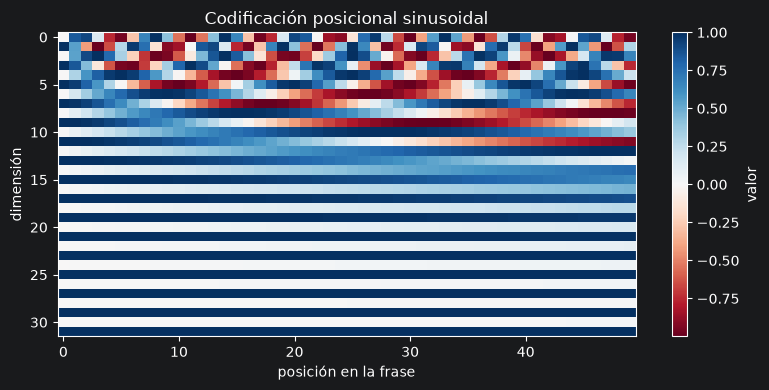

In [9]:
import matplotlib.pyplot as plt


def codificacion_posicional(n_posiciones, dim):
    posiciones = np.arange(n_posiciones)[:, None]
    i = np.arange(dim)[None, :]
    angulos = posiciones / (10000 ** (2 * (i // 2) / dim))
    pe = np.zeros((n_posiciones, dim))
    pe[:, 0::2] = np.sin(angulos[:, 0::2])
    pe[:, 1::2] = np.cos(angulos[:, 1::2])
    return pe


pe = codificacion_posicional(n_posiciones=50, dim=32)

plt.figure(figsize=(8, 4))
plt.imshow(pe.T, aspect="auto", cmap="RdBu")
plt.xlabel("posición en la frase")
plt.ylabel("dimensión")
plt.title("Codificación posicional sinusoidal")
plt.colorbar(label="valor")
plt.tight_layout()
plt.show()

Las dimensiones bajas oscilan rápido (distinguen posiciones vecinas) y las
altas oscilan lento (distinguen el inicio del final del texto). Los valores
quedan acotados entre −1 y 1, y como es una función matemática (no una
tabla aprendida), el modelo puede extrapolar a textos más largos que los
vistos en entrenamiento. Queda un costo: comparar todas las palabras con
todas hace que el cómputo crezca con el cuadrado de la longitud del texto.

## BERT y GPT: qué se les permite mirar

La diferencia entre las dos familias de Transformers está en qué palabras
puede mirar cada una al calcular su atención:

| | Dirección | Se entrena | Sirve para |
|---|---|---|---|
| **BERT** | ambos lados | tapar una palabra y adivinarla viendo antes y después | clasificar, buscar, extraer información |
| **GPT** | solo hacia atrás | predecir la siguiente palabra sin ver el final | generar, resumir, conversar |

Esa restricción de GPT es justo lo que permite entrenar con cualquier texto
de internet sin etiquetar nada — de ahí salen los modelos de lenguaje
actuales.

## SBERT: un vector por oración, no por palabra

BERT entrega un vector por palabra, no por documento. Comparar una consulta
contra 10 000 documentos pasando cada par junto por BERT obligaría a
correr el modelo 10 000 veces. **SBERT** (Reimers & Gurevych, 2019) resuelve
esto entrenando el modelo para que la cercanía entre vectores de *oraciones
completas* refleje su similitud de significado: cada documento se vectoriza
**una sola vez** y las búsquedas se reducen a comparar vectores ya
calculados con el coseno (arquitectura *bi-encoder*). Es lo que hace viable
la búsqueda semántica y los sistemas RAG en producción.

## Ejercicio 03 — Buscador semántico

**Objetivo:** construir un buscador que encuentre productos por significado
y no por coincidencia de palabras, y comparar en qué casos supera a TF-IDF
y en cuáles queda por debajo.

In [5]:
import pandas as pd
from sentence_transformers import SentenceTransformer

productos = pd.read_csv("../data/productos.csv")
sbert = SentenceTransformer(MODEL_NAME)

embeddings_productos = sbert.encode(
    productos["descripcion"].tolist(), convert_to_numpy=True, normalize_embeddings=True
)
print(f"Embeddings: {embeddings_productos.shape}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Embeddings: (10, 384)


In [6]:
def buscar_semantico(consulta, top_k=3):
    vector_consulta = sbert.encode([consulta], normalize_embeddings=True)[0]
    similitudes = embeddings_productos @ vector_consulta
    top = similitudes.argsort()[::-1][:top_k]
    return [(productos.loc[i, "nombre_producto"], round(float(similitudes[i]), 3)) for i in top]


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf_productos = TfidfVectorizer()
X_tfidf_productos = tfidf_productos.fit_transform(productos["descripcion"])


def buscar_tfidf(consulta, top_k=3):
    vector_consulta = tfidf_productos.transform([consulta])
    similitudes = cosine_similarity(vector_consulta, X_tfidf_productos).ravel()
    top = similitudes.argsort()[::-1][:top_k]
    return [(productos.loc[i, "nombre_producto"], round(float(similitudes[i]), 3)) for i in top]

### Tanda 1 — consultas parafraseadas (sin palabras en común con el producto)

In [7]:
consultas_parafraseadas = [
    "algo para grabar mis aventuras al aire libre",
    "un libro para perderme en un mundo de magia",
    "quiero jugar videojuegos exigentes con gráficos potentes",
]
for consulta in consultas_parafraseadas:
    print(f"\n'{consulta}'")
    print("  SBERT :", buscar_semantico(consulta))
    print("  TF-IDF:", buscar_tfidf(consulta))


'algo para grabar mis aventuras al aire libre'
  SBERT : [('Cámara de Acción 4K', 0.435), ('Zapatillas Urbanas Fit', 0.324), ('Camiseta Deportiva Ultralight', 0.298)]
  TF-IDF: [('Balón de Fútbol Pro', 0.183), ('Cámara de Acción 4K', 0.112), ('Mochila Urbana Tech', 0.095)]

'un libro para perderme en un mundo de magia'
  SBERT : [('Libro: El Círculo Mágico', 0.524), ('Zapatillas Urbanas Fit', 0.122), ('Camiseta Deportiva Ultralight', 0.109)]
  TF-IDF: [('Libro: El Círculo Mágico', 0.275), ('Balón de Fútbol Pro', 0.268), ('Auriculares Inalámbricos X', 0.235)]

'quiero jugar videojuegos exigentes con gráficos potentes'
  SBERT : [('Cámara de Acción 4K', 0.452), ('Laptop Gamer Pro', 0.426), ('Balón de Fútbol Pro', 0.255)]
  TF-IDF: [('Mochila Urbana Tech', 0.216), ('Smartphone Nexus 5G', 0.154), ('Laptop Gamer Pro', 0.145)]


### Tanda 2 — consultas con términos técnicos exactos

In [8]:
consultas_exactas = ["RTX 4080", "108MP", "DDR5"]
for consulta in consultas_exactas:
    print(f"\n'{consulta}'")
    print("  SBERT :", buscar_semantico(consulta))
    print("  TF-IDF:", buscar_tfidf(consulta))


'RTX 4080'
  SBERT : [('Laptop Gamer Pro', 0.373), ('Cámara de Acción 4K', 0.292), ('Smartphone Nexus 5G', 0.259)]
  TF-IDF: [('Laptop Gamer Pro', 0.169), ('Cámara de Acción 4K', 0.0), ('Mochila Urbana Tech', 0.0)]

'108MP'
  SBERT : [('Laptop Gamer Pro', 0.389), ('Cámara de Acción 4K', 0.357), ('Auriculares Inalámbricos X', 0.317)]
  TF-IDF: [('Smartphone Nexus 5G', 0.127), ('Cámara de Acción 4K', 0.0), ('Mochila Urbana Tech', 0.0)]

'DDR5'
  SBERT : [('Laptop Gamer Pro', 0.392), ('Smartphone Nexus 5G', 0.325), ('Mochila Urbana Tech', 0.235)]
  TF-IDF: [('Laptop Gamer Pro', 0.12), ('Cámara de Acción 4K', 0.0), ('Mochila Urbana Tech', 0.0)]


### Entregable: recomendación razonada

Con solo 10 productos el catálogo es chico, pero el patrón ya se nota en los
resultados de arriba:

| Tanda | Producto correcto en el top-1 | Producto correcto en el top-3 |
|---|---|---|
| Parafraseada — SBERT | 2 de 3 | 3 de 3 |
| Parafraseada — TF-IDF | 1 de 3 | 3 de 3 |
| Términos exactos — SBERT | 2 de 3 | 3 de 3 |
| Términos exactos — TF-IDF | 3 de 3 | 3 de 3 |

TF-IDF nunca falla con los códigos técnicos porque "108MP" o "DDR5" son
casi nombres propios y el matcheo es literal. SBERT los sitúa peor —
"108MP" termina más cerca de la laptop que del smartphone, porque el
embedding entiende "especificación técnica de electrónica" pero no lee la
sigla letra por letra. En las consultas parafraseadas ocurre lo contrario:
SBERT ubica el producto correcto primero incluso sin compartir palabras con
la descripción, mientras TF-IDF solo acierta el top-1 cuando hay alguna
coincidencia literal de fondo (como "libro").

Ninguno de los dos gana siempre: en producción los buscadores casi nunca
eligen un solo método, sino que combinan ambos enfoques (**búsqueda
híbrida**) — primero recuperan candidatos con los dos y luego reordenan
solo los mejores con un modelo más caro y preciso.

**Siguiente:** `06_sistema-recomendacion.ipynb` — usar estos mismos
embeddings de producto para recomendar, y el problema de agregarlos en un
perfil de cliente.